In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares, root
import h5py
import os
import warnings
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [142]:
## Disk parameters
alpha = 1e-3
M_disk = 0.1 # M_sun
T_0 = 18.9737 # K
a_c = 50 # AU
a_min = 0.1 # AU
a_max = 1000 # AU
d2g = 0.01
D = 0.2
b_tilde = 10
mu = 2.33
v_frag = 100 # cm/s
epsilon_g = 0.5

## Star parameters
M_star = 1.0 # M_sun
R_star = 2.5 # R_sun
T_eff = 4000 # K

## Planetesimal parameters
rho_pltsml = 2.0 # g/cm^3

## Embryo core parameters
rho_core = 2.0 # g/cm^3

## Constants
G = 6.67e-8 # cm^3/g/s^2
k_B = 1.38e-16 # erg/K
sigma_B = 5.67e-5 # erg/cm^2/s/K^4
m_H = 1.67e-24 # g
M_earth = 5.97e27 # g
M_sun = 1.99e33 # g
R_sun = 6.96e10 # cm
L_sun = 3.839e33 # erg/s
AU = 1.496e13 # cm
year = 3.156e7 # s
sigma_H2 = 2.61e-15 # cm^2

In [144]:
## Disk structure helper functions

def L_star(R_star, T_eff):
    """Calculates the stellar luminosity in solar luminosities assuming a blackbody."""
    return 4 * np.pi * (R_star * R_sun) ** 2 * sigma_B * T_eff ** 4 / L_sun

def Sigma_0(M_disk, a_c):
    """Calculates the normalization constant for the surface density profile."""
    return M_disk * M_sun / (2 * np.pi * (a_c * AU) ** 2)

def Sigma_g(a):
    """Calculates the gas surface density of the disk in g/cm^2."""
    return Sigma_0(M_disk, a_c) * (a / a_c) ** (-1) * np.exp(-a / a_c)

def Sigma_s(a):
    """Calculates the solid surface density of the disk in g/cm^2."""
    return d2g * Sigma_g(a)

def rho_mid(a):
    """Calculates the midplane gas density of the disk in g/cm^3."""
    return Sigma_g(a) / (np.sqrt(2 * np.pi) * H(a) * AU)

def T(a):
    """Calculates the temperature of the disk in K."""
    return T_0 * (a / a_c) ** (-0.5)

def c_s(a):
    """Calculates the sound speed of the disk in cm/s."""
    return np.sqrt(k_B * T(a) / (mu * m_H))

def H(a):
    """Calculates the scale height of the disk in AU."""
    return c_s(a) / Omega_K(a) / AU

def Reynolds(e2, i2, a):
    """Calculates the Reynolds number."""
    nu_mol = mfp_H2(a) * c_s(a) / 3
    return v_rel(e2, i2, a) * (R_pltsml(a) * 1e5) / nu_mol

def mfp_H2(a):
    """Calculates the mean free path of H2 in cm."""
    n_H2 = rho_mid(a) / (mu * m_H)
    return (n_H2 * sigma_H2) ** (-1)

def P(a):
    """Calculates the pressure of the disk in g/cm/s^2 assuming an ideal gas."""
    return rho_mid(a) * c_s(a) ** 2

def dP_da(a):
    """Calculates the pressure gradient of the disk at a."""
    a_vals = np.logspace(np.log10(a_min), np.log10(a_max), 10000) # AU
    P_vals = P(a_vals)
    dP_da_vals = np.gradient(P_vals, a_vals * AU)
    return np.interp(np.log10(a), np.log10(a_vals), dP_da_vals)

def dlnP_dlna(a):
    """Calculates dlnP/dlna of the disk at a."""
    return (a * AU) / P(a) * dP_da(a)

## Embryo and planetesimal helper functions

def v_rel(e2, i2, a_0):
    """Calculates the relative velocity between planetesimals and the embryo in cm/s (Fortier et al. 2012)."""
    return Omega_K(a_0) * a_0 * AU * np.sqrt(5/8 * e2 + 1/2 * i2)

def R_pltsml(a_0):
    """Calculates the planetesimal radius assuming constant density in km."""
    return (3 * M_pltsml(a_0) * M_earth / (4 * np.pi * rho_core)) ** (1/3) / 1e5

def M_pltsml(a_0):
    """Calculates the planetesimal mass in Earth masses assuming the birth mass from the streaming instability."""
    return M_birth(a_0)

def Omega_K(a):
    """Calculates the Keplerian angular velocity in rad/s."""
    return np.sqrt(G * M_star * M_sun / (a * AU) ** 3)

def R_core(M_core):
    """Calculates the core radius assuming a constant density in km."""
    return (3 * M_core * M_earth / (4 * np.pi * rho_core)) ** (1/3) / 1e5

def R_H(M_core, a_core):
    """Calculates the Hill radius in AU."""
    return a_core * (M_core * M_earth / (3 * M_star * M_sun)) ** (1/3)

def P_scatter(M_core, a_core):
    """Calculates the probbility that a planetesimal is scattered rather than accreted."""
    f_cap = ((2 * G * M_star * M_sun / (a_core * AU)) / (G * M_core * M_earth / (R_core(M_core) * 1e5))) ** 2
    return 1 / (1 + f_cap)

## Streaming instability birth mass

def M_birth(a):
    """Calculates the streaming instability brith mass in Earth masses (Johnston et al 2026)."""
    return 6e-2 * (gamma(a) * np.pi) ** 1.5 * (H(a) / a / 0.05) ** 3 * (M_star / 2.4)

def gamma(a):
    """Calculates the self-gravity parameter (Johnston et al 2026)."""
    return 4 * np.pi * G * rho_mid(a) / (Omega_K(a) ** 2)

## Eccentricity and inclination helper functions

def f_j(a_0, a_j, M_j):
    """Distance modulation function for embryo j (Kaufmann & Alibert 2023)."""
    return 1 / (1 + abs(a_0 - a_j) / (5 * R_H(M_j, a_j)))

def P_VS(e_tilde, i_tilde):
    """Stirring function for eccentricity (Kaufmann & Alibert 2023)."""
    Lambda = 1/12 * (e_tilde ** 2 + i_tilde ** 2) * i_tilde
    beta = i_tilde / e_tilde
    return (73 * e_tilde ** 2) / (10 * Lambda ** 2) * np.log(1 + 10 * Lambda ** 2 / (e_tilde ** 2)) + (72 * I_PVS(beta)) / (np.pi * e_tilde * i_tilde) * np.log(1 + Lambda ** 2)

def Q_VS(e_tilde, i_tilde):
    """Stirring function for inclination (Kaufmann & Alibert 2023)."""
    Lambda = 1/12 * (e_tilde ** 2 + i_tilde ** 2) * i_tilde
    beta = i_tilde / e_tilde
    return (4 * i_tilde ** 2 + 0.2 * i_tilde * e_tilde ** 3) / (10 * Lambda ** 2 * e_tilde) * np.log(1 + 10 * Lambda ** 2 * e_tilde) + (72 * I_QVS(beta)) / (np.pi * e_tilde * i_tilde) * np.log(1 + Lambda ** 2)

def I_PVS(beta):
    """Numerical elliptic integral approximation (Kaufmann & Alibert 2023)."""
    return (beta - 0.36251) / (0.061547 + 0.16112 * beta + 0.054473 * beta ** 2)

def I_QVS(beta):
    """Numerical elliptic integral approximation (Kaufmann & Alibert 2023)."""
    return (0.71946 - beta) / (0.21239 + 0.49764 * beta + 0.14369 * beta ** 2)

def t_stop(e2, i2, a_0):
    """Planetesimal gas drag stopping time in s (Kaufmann & Alibert 2023)."""

    if R_pltsml(a_0) * 1e5 < 1.5 * mfp_H2(a_0):
        return rho_pltsml * (R_pltsml(a_0) * 1e5) / (rho_mid(a_0) * c_s(a_0))
    
    else:
        if Reynolds(e2, i2, a_0) < 27:
            return 2 * rho_pltsml * (R_pltsml(a_0) * 1e5) ** 2 / (3 * rho_mid(a_0) * mfp_H2(a_0) * c_s(a_0))
        
        else:
            return 6 * rho_pltsml * (R_pltsml(a_0) * 1e5) / (rho_mid(a_0) * v_rel(e2, i2, a_0))

def e_tilde_embryo(e2, M_core):
    """Calculates the embryo reduced eccentricity."""
    return np.sqrt(np.maximum(e2, 0)) / (M_core * M_earth / (3 * M_star * M_sun)) ** (1/3)

def i_tilde_embryo(i2, M_core):
    """Calculates the embryo reduced inclination."""
    return np.sqrt(np.maximum(i2, 0)) / (M_core * M_earth / (3 * M_star * M_sun)) ** (1/3)

def e_tilde_pltsml(e2, a_0):
    """Calculates the planetesimal reduced eccentricity."""
    return 2 * np.sqrt(np.maximum(e2, 0)) / (2 * M_pltsml(a_0) * M_earth / (3 * M_star * M_sun)) ** (1/3)

def i_tilde_pltsml(i2, a_0):
    """Calculates the planetesimal reduced inclination."""
    return 2 * np.sqrt(np.maximum(i2, 0)) / (2 * M_pltsml(a_0) * M_earth / (3 * M_star * M_sun)) ** (1/3)

## Planetesimal accretion helper functions

def I_F(beta):
    """Numerical elliptic integral approximation (Fortier et al 2012)."""
    return (1 + 0.95925 * beta + 0.77251 * beta ** 2) / (beta * (0.13142 + 0.12295 * beta))

def I_G(beta):
    """Numerical elliptic integral approximation (Fortier et al 2012)."""
    return (1 + 0.3996 * beta) / (beta * (0.0369 + 0.048333 * beta + 0.006874 * beta ** 2))

def P_high(e2, i2, a_core, M_core):
    """Calculates the high collisional rate (Fortier et al 2012)."""
    e_tilde = e_tilde_embryo(e2, M_core)
    i_tilde = i_tilde_embryo(i2, M_core)
    beta = i_tilde / e_tilde
    return ((R_core(M_core) * 1e5 + R_pltsml(a_core) * 1e5) ** 2 / (2 * np.pi * (R_H(M_core, a_core) * AU) ** 2)) * (I_F(beta) + 6 * R_H(M_core, a_core) * AU * I_G(beta) / ((R_core(M_core) * 1e5 + R_pltsml(a_core) * 1e5) * e_tilde ** 2))

def P_med(e2, i2, a_core, M_core):
    """Calculates the medium collisional rate (Fortier et al 2012)."""
    e_tilde = e_tilde_embryo(e2, M_core)
    i_tilde = i_tilde_embryo(i2, M_core)
    beta = i_tilde / e_tilde
    return ((R_core(M_core) * 1e5 + R_pltsml(a_core) * 1e5) ** 2 / (4 * np.pi * (R_H(M_core, a_core) * AU) ** 2) * i_tilde) * (17.3 + 232 * R_H(M_core, a_core) * AU / (R_core(M_core) * 1e5 + R_pltsml(a_core) * 1e5))

def P_low(e2, i2, a_core, M_core):
    """Calculates the low colisional rate (Fortier et al 2012)."""
    e_tilde = e_tilde_embryo(e2, M_core)
    i_tilde = i_tilde_embryo(i2, M_core)
    beta = i_tilde / e_tilde
    return 11.3 * ((R_core(M_core) * 1e5 + R_pltsml(a_core) * 1e5) / (R_H(M_core, a_core) * AU)) ** (1/2)

def P_coll(e2, i2, a_core, M_core):
    """Calculates the probability that the planetesimal is accreted by the embryo (Fortier et al 2012)."""
    return np.min((P_med(e2, i2, a_core, M_core), (P_high(e2, i2, a_core, M_core) ** (-2) + P_low(e2, i2, a_core, M_core) ** (-2)) ** (-1/2)), axis = 0)

In [145]:
## Pebble accretion onset mass

def M_on(a):
    """Calculates the onset mass for pebble accretion in Earth masses (Lorek et al 2022)."""
    return 4.871e-7 * (tau_s(a) / 0.01) * M_star ** (-17/7) * L_star(R_star, T_eff) ** (6/7) * a ** (12/7)

def tau_s(a):
    """Calculates the Stokes number (Lorek et al 2022)."""
    return np.min((tau_s_frag(a), tau_s_drift(a)), axis = 0)

def tau_s_frag(a):
    """Calculates the fragmentation limited Stokes number (Lorek et al 2022)."""
    return v_frag ** 2 / (2 * alpha * c_s(a) ** 2)

def tau_s_drift(a):
    """Calculates the drift limited Stokes number (Lorek et al 2022)."""
    return 3 * np.sqrt(np.pi) / 4 * epsilon_g * d2g / eta(a)

def eta(a):
    """Calculates the eta parameter (Fortier et al 2012)."""
    return -1 * dP_da(a) / (2 * Omega_K(a) ** 2 * a * AU * rho_mid(a))

## Pebble accretion transition mass

def M_tr(a):
    """Calculates the transition mass from the Bondi to the Hill regime in Earth masses (Lorek et al 2022)."""
    return 1.125e-4 * M_star ** (-17/7) * L_star(R_star, T_eff) ** (6/7) * a ** (12/7)

## Pebble isolation mass

def M_iso_pebble(a):
    """Calculates the pebble isolation mass in Earth masses (Lorek et al 2022)."""
    return 25 * (H(a) / a / 0.05) ** 3 * (0.34 * (-3 / np.log10(alpha)) ** 4 + 0.66 ) * (1 - (dlnP_dlna(a) + 2.5) / 6)

## Planetesimal isolation mass

def M_iso_pltsml(a):
    """Calculates the planetesimal isolation mass in Earth masses (Rafikov 2011)."""
    return (2 * np.pi * (a * AU) ** 2 * b_tilde * Sigma_s(a)) ** (3/2) * (3 * M_star * M_sun) ** (-1/2) / M_earth

In [146]:
## Wrapper function for scipy.optimize.least_squares() or scipy.optimize.root()

def equilibrium(x, a_0, a_cores, M_cores, drag = True, VS_embryo = True, VS_pltsml = True, DF = True):
    """Returns [de2/dt, di2/dt] for a trial [e2, i2]."""
    e2, i2 = x

    return np.array([de2_dt(e2, i2, a_0, a_cores, M_cores, drag, VS_embryo, VS_pltsml, DF) * 1e6 * year, di2_dt(e2, i2, a_0, a_cores, M_cores, drag, VS_embryo, VS_pltsml, DF) * 1e6 * year])

## Wrapper function for scipy.integrate.solve_ivp()

t_print = 0
t_slack = 0

def odes(t, y, t_end, drag = True, VS_embryo = True, VS_pltsml = True, DF = True, accretion = True, scatter = False):
    """Wrapper function for coupled eccentricity, inclination, and embryo mass evolution OEDs for scipy.integrate.solve_ivp."""

    n_cores = len(y) // 4

    e2_vals, i2_vals, a_cores, M_cores = y[:n_cores], y[n_cores:2 * n_cores], y[2 * n_cores:3 * n_cores], y[3 * n_cores:4 * n_cores]

    global t_print, t_slack

    if t >= t_print + 1e5 * year:
        t_print += 1e5 * year

        print(f'Time = {t / (1e6 * year):.1f} Myr')

    if t >= t_slack + 0.5e6 * year:
        t_slack += 0.5e6 * year

        send_slack_message(f'Integration time = {t / (1e6 * year)} Myr\n'
                           f'Integration is {t / (t_end * 1e6 * year) * 100:.2f} % complete')
    
    de2_dt_vals = np.zeros(n_cores)
    di2_dt_vals = np.zeros(n_cores)
    da_dt_vals = np.zeros(n_cores)
    dM_dt_vals = np.zeros(n_cores)

    for j in range(n_cores):
        a_0 = a_cores[j]
        e2 = e2_vals[j]
        i2 = i2_vals[j]
        M_core = M_cores[j]

        de2_dt_vals[j] = de2_dt(e2, i2, a_0, a_cores, M_cores, drag, VS_embryo, VS_pltsml, DF)
        di2_dt_vals[j] = di2_dt(e2, i2, a_0, a_cores, M_cores, drag, VS_embryo, VS_pltsml, DF)

        da_dt_vals[j] = 0

        if accretion:
            dM_dt_vals[j] = dM_dt(e2, i2, a_0, M_core)

        if scatter:
            dM_dt_vals[j] *= P_scatter(M_core, a_0)

    return np.concatenate([de2_dt_vals, di2_dt_vals, da_dt_vals, dM_dt_vals])

## ODEs

def de2_dt(e2, i2, a_0, a_cores, M_cores, drag = True, VS_embryo = True, VS_pltsml = True, DF = True):
    """Evolution equation for local planetesimal eccentricity squared (Kaufmann & Alibert 2023)."""
    e2_dot = 0

    if drag:
        e2_dot += de2_dt_drag(e2, i2, a_0)

    if VS_embryo:
        e2_dot += de2_dt_VS_embryo(e2, i2, a_0, a_cores, M_cores)

    if VS_pltsml:
        e2_dot += de2_dt_VS_pltsml(e2, i2, a_0)

    if DF:
        e2_dot += de2_dt_DF(e2, i2, a_0)
    
    return e2_dot

def di2_dt(e2, i2, a_0, a_cores, M_cores, drag = True, VS_embryo = True, VS_pltsml = True, DF = True):
    """Evolution equation for local planetesimal inclination squared (Kaufmann & Alibert 2023)."""
    i2_dot = 0

    if drag:
        i2_dot += di2_dt_drag(e2, i2, a_0)

    if VS_embryo:
        i2_dot += di2_dt_VS_embryo(e2, i2, a_0, a_cores, M_cores)

    if VS_pltsml:
        i2_dot += di2_dt_VS_pltsml(e2, i2, a_0)

    if DF:
        i2_dot += di2_dt_DF(e2, i2, a_0)
    
    return i2_dot

## Gas drag terms

def de2_dt_drag(e2, i2, a_0):
    """Gas drag term in eccentricity evolution (Kaufmann & Alibert 2023)."""

    if R_pltsml(a_0) * 1e5 < 1.5 * mfp_H2(a_0):
        return -1 * e2 * c_s(a_0) * rho_mid(a_0) / (rho_pltsml * R_pltsml(a_0) * 1e5)
    
    else:
        if Reynolds(e2, i2, a_0) < 27:
            return -3/2 * e2 * mfp_H2(a_0) * c_s(a_0) * rho_mid(a_0) / (rho_pltsml * (R_pltsml(a_0) * 1e5) ** 2)
        
        else:
            return -2 * e2 * v_rel(e2, i2, a_0) * rho_mid(a_0) / (6 * rho_pltsml * R_pltsml(a_0) * 1e5)

def di2_dt_drag(e2, i2, a_0):
    """Gas drag term in inclination evolution (Kaufmann & Alibert 2023)."""

    if R_pltsml(a_0) * 1e5 < 1.5 * mfp_H2(a_0):
        return -1/2 * i2 * c_s(a_0) * rho_mid(a_0) / (rho_pltsml * R_pltsml(a_0) * 1e5)
    
    else:
        if Reynolds(e2, i2, a_0) < 27:
            return -3/4 * i2 * mfp_H2(a_0) * c_s(a_0) * rho_mid(a_0) / (rho_pltsml * (R_pltsml(a_0) * 1e5) ** 2)
        
        else:
            return -1 * i2 * v_rel(e2, i2, a_0) * rho_mid(a_0) / (6 * rho_pltsml * R_pltsml(a_0) * 1e5)
        
## Planetesimal viscous stirring terms

def de2_dt_VS_pltsml(e2, i2, a_0):
    """Viscous stirring due to planetesimal-planetesimal interactions (Fortier et al 2012)."""
    e_tilde = e_tilde_pltsml(e2, a_0)
    i_tilde = i_tilde_pltsml(i2, a_0)
    return 1/6 * np.sqrt(G * a_0 * AU / (M_star * M_sun)) * Sigma_s(a_0) * (2 * M_pltsml(a_0) * M_earth / (3 * M_star * M_sun)) ** (1/3) * P_VS(e_tilde, i_tilde)

def di2_dt_VS_pltsml(e2, i2, a_0):
    """Viscous stirring due to planetesimal-planetesimal interactions (Fortier et al 2012)."""
    e_tilde = e_tilde_pltsml(e2, a_0)
    i_tilde = i_tilde_pltsml(i2, a_0)
    return 1/6 * np.sqrt(G * a_0 * AU / (M_star * M_sun)) * Sigma_s(a_0) * (2 * M_pltsml(a_0) * M_earth / (3 * M_star * M_sun)) ** (1/3) * Q_VS(e_tilde, i_tilde)

## Embryo viscous stirring terms

def de2_dt_VS_embryo(e2, i2, a_0, a_cores, M_cores):
    """Viscous stirring due to all embryos acting on planetesimals local to a_0 (Kaufmann & Alibert 2023)."""
    e2_VS = 0
    for a_j, M_j in zip(a_cores, M_cores):
        e_tilde = e_tilde_embryo(e2, M_j)
        i_tilde = i_tilde_embryo(i2, M_j)
        e2_VS += f_j(a_0, a_j, M_j) * Omega_K(a_0) * M_j * M_earth / (6 * np.pi * b_tilde * M_star * M_sun) * P_VS(e_tilde, i_tilde)
    return e2_VS

def di2_dt_VS_embryo(e2, i2, a_0, a_cores, M_cores):
    """Viscous stirring due to all embryos acting on planetesimals local to a_0 (Kaufmann & Alibert 2023)."""
    i2_VS = 0
    for a_j, M_j in zip(a_cores, M_cores):
        e_tilde = e_tilde_embryo(e2, M_j)
        i_tilde = i_tilde_embryo(i2, M_j)
        i2_VS += f_j(a_0, a_j, M_j) * Omega_K(a_0) * M_j * M_earth / (6 * np.pi * b_tilde * M_star * M_sun) * Q_VS(e_tilde, i_tilde)
    return i2_VS

## Density fluctuations stirring terms

def de2_dt_DF(e2, i2, a_0):
    """Density fluctuation term in eccentricity evolution (Kaufmann & Alibert 2023)."""
    return 400 * alpha * (H(a_0) * AU * a_0 * AU * Sigma_g(a_0) / (M_star * M_sun)) ** 2 * Omega_K(a_0) + (4 * alpha / (3 * Omega_K(a_0) * t_stop(e2, i2, a_0) ** 2)) * (c_s(a_0) / (Omega_K(a_0) * a_0 * AU)) ** 2

def di2_dt_DF(e2, i2, a_0):
    """Density fluctuation term in inclination evolution (Kaufmann & Alibert 2023)."""
    return 4 * alpha * (H(a_0) * AU * a_0 * AU * Sigma_g(a_0) / (M_star * M_sun)) ** 2 * Omega_K(a_0) + (2 * alpha / (3 * Omega_K(a_0) * t_stop(e2, i2, a_0) ** 2)) * (c_s(a_0) / (Omega_K(a_0) * a_0 * AU)) ** 2

## Planetesimal core accretion term

def dM_dt(e2, i2, a_core, M_core):
    """Calculates the planetesimal core accretion rate in M_earth/s (Fortier et al 2012)."""
    return Sigma_s(a_core) * Omega_K(a_core) * (R_H(M_core, a_core) * AU) ** 2 * P_coll(e2, i2, a_core, M_core) / M_earth

In [147]:
def plot_results(a_cores, results, figure_dir):

    if not(os.path.exists(figure_dir)):
        os.makedirs(figure_dir)
    
    for a_0 in a_cores:

        print(f'Plotting results for a_0 = {a_0} AU...')

        fig, ax = plt.subplots(2, 2, figsize = (16, 12))

        fig.suptitle(f'Model Results: a_0 = {a_0} AU', fontsize = 16)

        ## Unpack results
        t_Myr = results[a_0]['t_Myr']
        e = results[a_0]['e']
        e2 = results[a_0]['e2']
        i2 = results[a_0]['i2']
        M = results[a_0]['M']
        M_dot = results[a_0]['M_dot']

        e_drag = results[a_0]['e_terms']['drag']
        e_VS_embryo = results[a_0]['e_terms']['VS_embryo']
        e_VS_pltsml = results[a_0]['e_terms']['VS_pltsml']
        e_DF = results[a_0]['e_terms']['DF']

        e2_dot = results[a_0]['e2_dot']
        e2_dot_drag = results[a_0]['e2_dot_terms']['drag']
        e2_dot_VS_embryo = results[a_0]['e2_dot_terms']['VS_embryo']
        e2_dot_VS_pltsml = results[a_0]['e2_dot_terms']['VS_pltsml']
        e2_dot_DF = results[a_0]['e2_dot_terms']['DF']

        ## Calcuate accretion rates
        M_dot_low = Sigma_s(a_0) * Omega_K(a_0) * (R_H(M, a_0) * AU) ** 2 * P_low(e2, i2, a_0, M) / M_earth
        M_dot_med = Sigma_s(a_0) * Omega_K(a_0) * (R_H(M, a_0) * AU) ** 2 * P_med(e2, i2, a_0, M) / M_earth
        M_dot_high = Sigma_s(a_0) * Omega_K(a_0) * (R_H(M, a_0) * AU) ** 2 * P_high(e2, i2, a_0, M) / M_earth

        ## Top Left: e vs t

        ax[0, 0].plot(t_Myr, np.where(e > 0, e, np.nan), color = 'k', linestyle = '-', label = r'$e(t)$')
        ax[0, 0].plot(t_Myr, np.where(e < 0, -1 * e, np.nan), color = 'k', linestyle = '--')

        ## Drag
        ax[0, 0].plot(t_Myr, np.where(e_drag > 0, e_drag, np.nan), color = 'tab:blue', linestyle = '-', label = 'Drag')
        ax[0, 0].plot(t_Myr, np.where(e_drag < 0, -1 * e_drag, np.nan), color = 'tab:blue', linestyle = '--')

        ## VS_embryo
        ax[0, 0].plot(t_Myr, np.where(e_VS_embryo > 0, e_VS_embryo, np.nan), color = 'tab:red', linestyle = '-', label = 'Embryo Stirring')
        ax[0, 0].plot(t_Myr, np.where(e_VS_embryo < 0, -1 * e_VS_embryo, np.nan), color = 'tab:red', linestyle = '--')

        ## VS_pltsml
        ax[0, 0].plot(t_Myr, np.where(e_VS_pltsml > 0, e_VS_pltsml, np.nan), color = 'tab:orange', linestyle = '-', label = 'Planetesimal Stirring')
        ax[0, 0].plot(t_Myr, np.where(e_VS_pltsml < 0, -1 * e_VS_pltsml, np.nan), color = 'tab:orange', linestyle = '--')

        ## DF
        ax[0, 0].plot(t_Myr, np.where(e_DF > 0, e_DF, np.nan), color = 'tab:green', linestyle = '-', label = 'Density Fluctuations')
        ax[0, 0].plot(t_Myr, np.where(e_DF < 0, -1 * e_DF, np.nan), color = 'tab:green', linestyle = '--')

        ax[0, 0].axhline(e[0], color = 'grey', linestyle = '--', label = r'$e_{eq}$')

        ax[0, 0].set_yscale('log')
        ax[0, 0].set_xlabel(r't [Myr]')
        ax[0, 0].set_ylabel(r'$e$')
        ax[0, 0].set_title(fr'$e(t)$: {a_0} AU')
        ax[0, 0].margins(0)
        ax[0, 0].legend()

        ## Top Right: de2/dt vs t

        ax[0, 1].plot(t_Myr, np.where(e2_dot * year > 0, e2_dot * year, np.nan), color = 'k', linestyle = '-', label = r'$\dot e^2(t)$')
        ax[0, 1].plot(t_Myr, np.where(e2_dot * year < 0, -1 * e2_dot * year, np.nan), color = 'k', linestyle = '--')
        
        ## Drag
        ax[0, 1].plot(t_Myr, np.where(e2_dot_drag * year > 0, e2_dot_drag * year, np.nan), color = 'tab:blue', linestyle = '-', label = 'Drag')
        ax[0, 1].plot(t_Myr, np.where(e2_dot_drag * year < 0, -1 * e2_dot_drag * year, np.nan), color = 'tab:blue', linestyle = '--')

        ## VS_embryo
        ax[0, 1].plot(t_Myr, np.where(e2_dot_VS_embryo * year > 0, e2_dot_VS_embryo * year, np.nan), color = 'tab:red', linestyle = '-', label = 'Embryo Stirring')
        ax[0, 1].plot(t_Myr, np.where(e2_dot_VS_embryo * year < 0, -1 * e2_dot_VS_embryo * year, np.nan), color = 'tab:red', linestyle = '--')

        ## VS_pltsml
        ax[0, 1].plot(t_Myr, np.where(e2_dot_VS_pltsml * year > 0, e2_dot_VS_pltsml * year, np.nan), color = 'tab:orange', linestyle = '-', label = 'Planetesimal Stirring')
        ax[0, 1].plot(t_Myr, np.where(e2_dot_VS_pltsml * year < 0, -1 * e2_dot_VS_pltsml * year, np.nan), color = 'tab:orange', linestyle = '--')

        ## DF
        ax[0, 1].plot(t_Myr, np.where(e2_dot_DF * year > 0, 1 * e2_dot_DF * year, np.nan), color = 'tab:green', linestyle = '-', label = 'Density Fluctuations')
        ax[0, 1].plot(t_Myr, np.where(e2_dot_DF * year < 0, -1 * e2_dot_DF * year, np.nan), color = 'tab:green', linestyle = '--')

        ax[0, 1].set_ylim(1e-18, 1e-4)
        ax[0, 1].set_yscale('log')
        ax[0, 1].set_xlabel(r't [Myr]')
        ax[0, 1].set_ylabel(r'$de^2/dt$ [year$^{-1}$]')
        ax[0, 1].set_title(fr'$\dot e^2$: {a_0} AU')
        ax[0, 1].margins(0)
        ax[0, 1].legend()

        ## Bottom Left: M vs t

        ax[1, 0].plot(t_Myr, M, color = 'k', label = r'$M_{core}(t)$')
        ax[1, 0].axhline(M[0], color = 'k', linestyle = '--', label = r'$M_{init}$')
        ax[1, 0].axhline(M_iso_pltsml(a_0), color = 'k', linestyle = 'dotted', label = r'$M_{iso, pltsml}$')

        ax[1, 0].axhspan(1e-8, M_on(a_0), color = 'red', alpha = 0.5, label = r'$M < M_{on}$')
        ax[1, 0].axhspan(M_on(a_0), M_tr(a_0), color = 'yellow', alpha = 0.5, label = r'$M < M_{tr}$')
        ax[1, 0].axhspan(M_tr(a_0), M_iso_pebble(a_0), color = 'green', alpha = 0.5, label = r'$M < M_{iso, pebble}$')
        ax[1, 0].axhspan(M_iso_pebble(a_0), 1e4, color = 'red', alpha = 0.5, label = r'$M > M_{iso, pebble}$')

        ax[0, 1].set_ylim(1e-8, 1e4)
        ax[1, 0].set_yscale('log')
        ax[1, 0].set_xlabel(r't [Myr]')
        ax[1, 0].set_ylabel(r'$M_{core}$ [$M_\oplus$]')
        ax[1, 0].set_title(fr'$M(t)$: {a_0} AU')
        ax[1, 0].margins(0)
        ax[1, 0].legend()

        ## Bottom Right: dM/dt vs t

        ax[1, 1].plot(t_Myr, M_dot * year, color = 'k', label = r'$\dot M_{core}(t)$')
        ax[1, 1].plot(t_Myr, M_dot_low * year, color = 'tab:blue', linestyle = 'dotted', label = r'$\dot M_{core, low}(t)$')
        ax[1, 1].plot(t_Myr, M_dot_med * year, color = 'tab:orange', linestyle = 'dotted', label = r'$\dot M_{core, med}(t)$')
        ax[1, 1].plot(t_Myr, M_dot_high * year, color = 'tab:green', linestyle = 'dotted', label = r'$\dot M_{core, high}(t)$')

        ax[1, 1].set_ylim(1e-12, 1e-2)
        ax[1, 1].set_yscale('log')
        ax[1, 1].set_xlabel(r't [Myr]')
        ax[1, 1].set_ylabel(r'$\dot M_{core}$ [$M_\oplus$/year]')
        ax[1, 1].set_title(fr'$\dot M(t)$: {a_0} AU')
        ax[1, 1].margins(0)
        ax[1, 1].legend()

        plt.tight_layout()
        plt.savefig(f'{figure_dir}acore_{a_0}.png', bbox_inches = 'tight')

    print('All plots saved.')

In [ ]:
def run_model(a_cores, t_end, t_interval, output_dir, drag = True, VS_embryo = True, VS_pltsml = True, DF = True, accretion = True, scatter = False):
    """Runs the ODE solver with the specified terms. Saves results to output_dir and figures to figure_dir."""
    
    ## Construct initial conditions
    n_cores = len(a_cores)
    M_cores_init = M_birth(a_cores)

    e2_eq_init = np.zeros(n_cores)
    i2_eq_init = np.zeros(n_cores)

    for j in range(n_cores):
        a_0 = a_cores[j]

        ### Solve for numerical equilibrium eccentricity and inclination
        sol = root(equilibrium, x0 = np.array([0.1 ** 2, (0.1 / 2) ** 2]), args = (a_0, a_cores, M_cores_init, drag, VS_embryo, VS_pltsml, DF), tol = 1e-12)
        e2_eq, i2_eq = sol.x

        e2_eq_init[j] = e2_eq
        i2_eq_init[j] = i2_eq

    init = np.concatenate([e2_eq_init, i2_eq_init, a_cores, M_cores_init])

    ## Solve ODEs

    print('Beginning ODE integration...')

    t_eval = np.arange(0, t_end * 1e6 * year + t_interval * year, t_interval * year)

    ivp_solution = solve_ivp(odes, (0, t_end * 1e6 * year), init, method = "RK45", max_step = 10 * year, t_eval = t_eval, args = (t_end, drag, VS_embryo, VS_pltsml, DF, accretion, scatter))

    print('ODE integration complete!')
    
    print(f'IntegrationSuccess: {ivp_solution.success}')
    print(f'Message: {ivp_solution.message}')
    print(f'Final time: {ivp_solution.t[-1] / (1e6 * year)} Myr')

    ## Process results

    print('Processing results...')

    t = ivp_solution.t
    t_Myr = t / (1e6 * year)

    sol = ivp_solution.y
    e2_sol, i2_sol, a_cores_sol, M_sol = sol[0:n_cores], sol[n_cores:2 * n_cores], sol[2 * n_cores:3 * n_cores], sol[3 * n_cores:4 * n_cores]

    e_sol = np.sqrt(e2_sol)
    i_sol = np.sqrt(i2_sol)

    results = {}

    for j in range(n_cores):
        e2 = e2_sol[j]
        i2 = i2_sol[j]
        a = a_cores[j]
        M = M_sol[j]
        e = e_sol[j]
        i = i_sol[j]

        ## Calculate derivative terms
        e2_dot = np.array([de2_dt(e2_k, i2_k, a, a_cores, M_cores_k) for e2_k, i2_k, M_cores_k in zip(e2, i2, M_sol.T)])
        i2_dot = np.array([di2_dt(e2_k, i2_k, a, a_cores, M_cores_k) for e2_k, i2_k, M_cores_k in zip(e2, i2, M_sol.T)])
        M_dot = np.array([dM_dt(e2_k, i2_k, a, M_k) for e2_k, i2_k, M_k in zip(e2, i2, M)])

        e2_dot_drag = np.array([de2_dt_drag(e2_k, i2_k, a) for e2_k, i2_k in zip(e2, i2)])
        e2_dot_VS_embryo = np.array([de2_dt_VS_embryo(e2_k, i2_k, a, a_cores, M_cores_k) for e2_k, i2_k, M_cores_k in zip(e2, i2, M_sol.T)])
        e2_dot_VS_pltsml = np.array([de2_dt_VS_pltsml(e2_k, i2_k, a) for e2_k, i2_k in zip(e2, i2)])
        e2_dot_DF = np.array([de2_dt_DF(e2_k, i2_k, a) for e2_k, i2_k in zip(e2, i2)])

        i2_dot_drag = np.array([di2_dt_drag(e2_k, i2_k, a) for e2_k, i2_k in zip(e2, i2)])
        i2_dot_VS_embryo = np.array([di2_dt_VS_embryo(e2_k, i2_k, a, a_cores, M_cores_k) for e2_k, i2_k, M_cores_k in zip(e2, i2, M_sol.T)])
        i2_dot_VS_pltsml = np.array([di2_dt_VS_pltsml(e2_k, i2_k, a) for e2_k, i2_k in zip(e2, i2)])
        i2_dot_DF = np.array([di2_dt_DF(e2_k, i2_k, a) for e2_k, i2_k in zip(e2, i2)])

        ## Integrate derivative terms to get contributions to e2 and i2
        e2_drag, i2_drag = [e2[0]], [i2[0]]
        e2_VS_embryo, i2_VS_embryo = [e2[0]], [i2[0]]
        e2_VS_pltsml, i2_VS_pltsml = [e2[0]], [i2[0]]
        e2_DF, i2_DF = [e2[0]], [i2[0]]

        for k in range(len(t) - 1):
            dt = t[k + 1] - t[k]

            e2_drag.append(e2_drag[-1] + e2_dot_drag[k] * dt)
            e2_VS_embryo.append(e2_VS_embryo[-1] + e2_dot_VS_embryo[k] * dt)
            e2_VS_pltsml.append(e2_VS_pltsml[-1] + e2_dot_VS_pltsml[k] * dt)
            e2_DF.append(e2_DF[-1] + e2_dot_DF[k] * dt)

            i2_drag.append(i2_drag[-1] + i2_dot_drag[k] * dt)
            i2_VS_embryo.append(i2_VS_embryo[-1] + i2_dot_VS_embryo[k] * dt)
            i2_VS_pltsml.append(i2_VS_pltsml[-1] + i2_dot_VS_pltsml[k] * dt)
            i2_DF.append(i2_DF[-1] + i2_dot_DF[k] * dt)

        ## Store results in dictionary
        results[a] = {
            't': t,
            't_Myr': t_Myr,

            'e2': e2,
            'i2': i2,
            'e': e,
            'i': i,

            'a': a,
            'M': M,
            'v_rel': v_rel(e2, i2, a),

            'e2_dot': e2_dot,
            'i2_dot': i2_dot,
            'M_dot': M_dot,

            'e_terms': {
                'drag': np.sign(e2_drag) * np.sqrt(np.abs(e2_drag)),
                'VS_embryo': np.sign(e2_VS_embryo) * np.sqrt(np.abs(e2_VS_embryo)),
                'VS_pltsml': np.sign(e2_VS_pltsml) * np.sqrt(np.abs(e2_VS_pltsml)),
                'DF': np.sign(e2_DF) * np.sqrt(np.abs(e2_DF))},

            'i_terms': {
                'drag': np.sign(i2_drag) * np.sqrt(np.abs(i2_drag)),
                'VS_embryo': np.sign(i2_VS_embryo) * np.sqrt(np.abs(i2_VS_embryo)),
                'VS_pltsml': np.sign(i2_VS_pltsml) * np.sqrt(np.abs(i2_VS_pltsml)),
                'DF': np.sign(i2_DF) * np.sqrt(np.abs(i2_DF))},

            'e2_dot_terms': {
                'drag': e2_dot_drag,
                'VS_embryo': e2_dot_VS_embryo,
                'VS_pltsml': e2_dot_VS_pltsml,
                'DF': e2_dot_DF},
                                        
            'i2_dot_terms': {
                'drag': i2_dot_drag,
                'VS_embryo': i2_dot_VS_embryo,
                'VS_pltsml': i2_dot_VS_pltsml,
                'DF': i2_dot_DF}}
    
    with h5py.File(output_dir, "w") as h5f:
        for a_key, a_result in results.items():
            group = h5f.create_group(str(a_key))

            for key, value in a_result.items():
                if isinstance(value, dict):
                    subgroup = group.create_group(key)

                    for subkey, subvalue in value.items():
                        subgroup.create_dataset(subkey, data = np.asarray(subvalue))

                else:
                    group.create_dataset(key, data = np.asarray(value))

    print('Results processed!')
    
    return results

In [149]:
def load_results(output_dir):
    """Loads results from an HDF5 file and returns a nested dictionary."""

    results = {}

    with h5py.File(output_dir, "r") as h5f:

        for a_key in h5f.keys():
            a = float(a_key)
            results[a] = {}

            for key in h5f[a_key].keys():
                item = h5f[a_key][key]

                if isinstance(item, h5py.Dataset):
                    results[a][key] = item[()]

                elif isinstance(item, h5py.Group):
                    results[a][key] = {}

                    for subkey in item.keys():
                        results[a][key][subkey] = item[subkey][()]

    return results

Loading results from "/Users/ben/Downloads/Planet Formation/Bern Model Simulations/Output/ncores_11_Mdisk_0.1_tend_3.0_scatter.h5"...
Plotting results and saving figures to "/Users/ben/Downloads/Planet Formation/Bern Model Simulations/Figures/ncores_11_Mdisk_0.1_tend_3.0_scatter/"...
Plotting results for a_0 = 1.0 AU...
Plotting results for a_0 = 2.0 AU...
Plotting results for a_0 = 3.0 AU...
Plotting results for a_0 = 4.0 AU...
Plotting results for a_0 = 5.0 AU...
Plotting results for a_0 = 6.0 AU...
Plotting results for a_0 = 10.0 AU...
Plotting results for a_0 = 15.0 AU...
Plotting results for a_0 = 20.0 AU...
Plotting results for a_0 = 25.0 AU...
Plotting results for a_0 = 30.0 AU...
All plots saved.


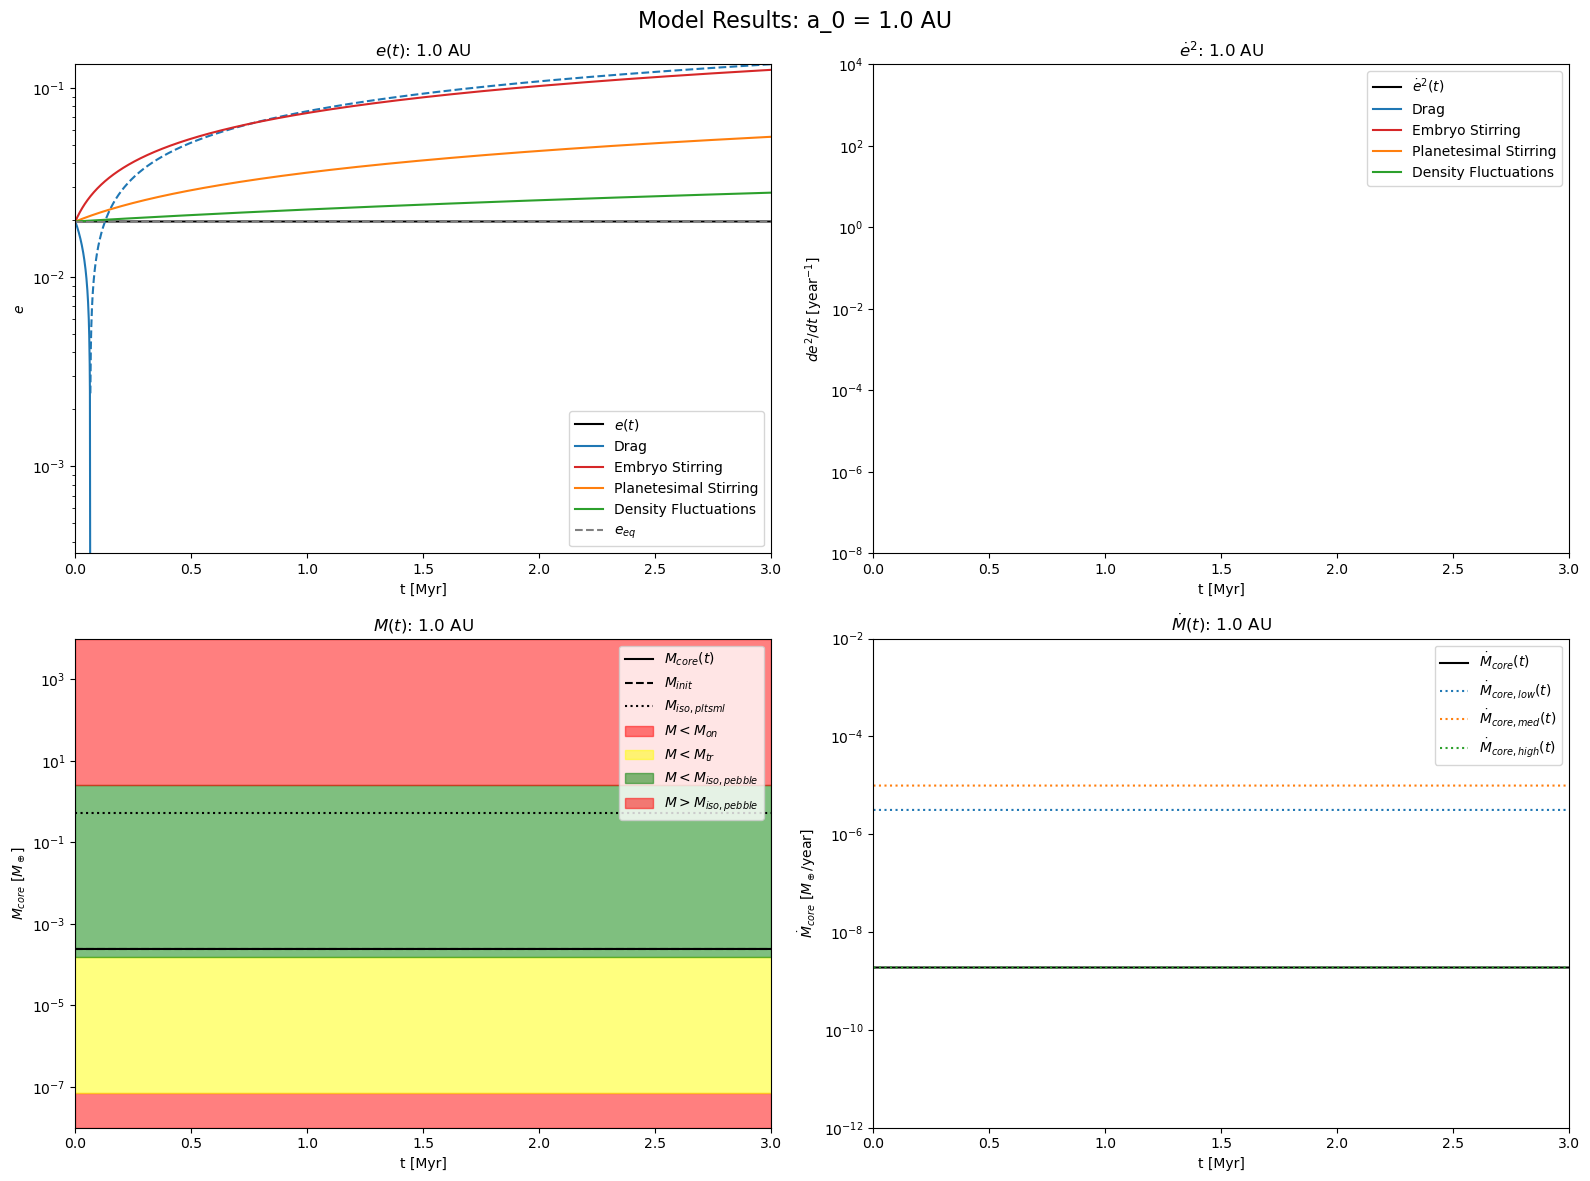

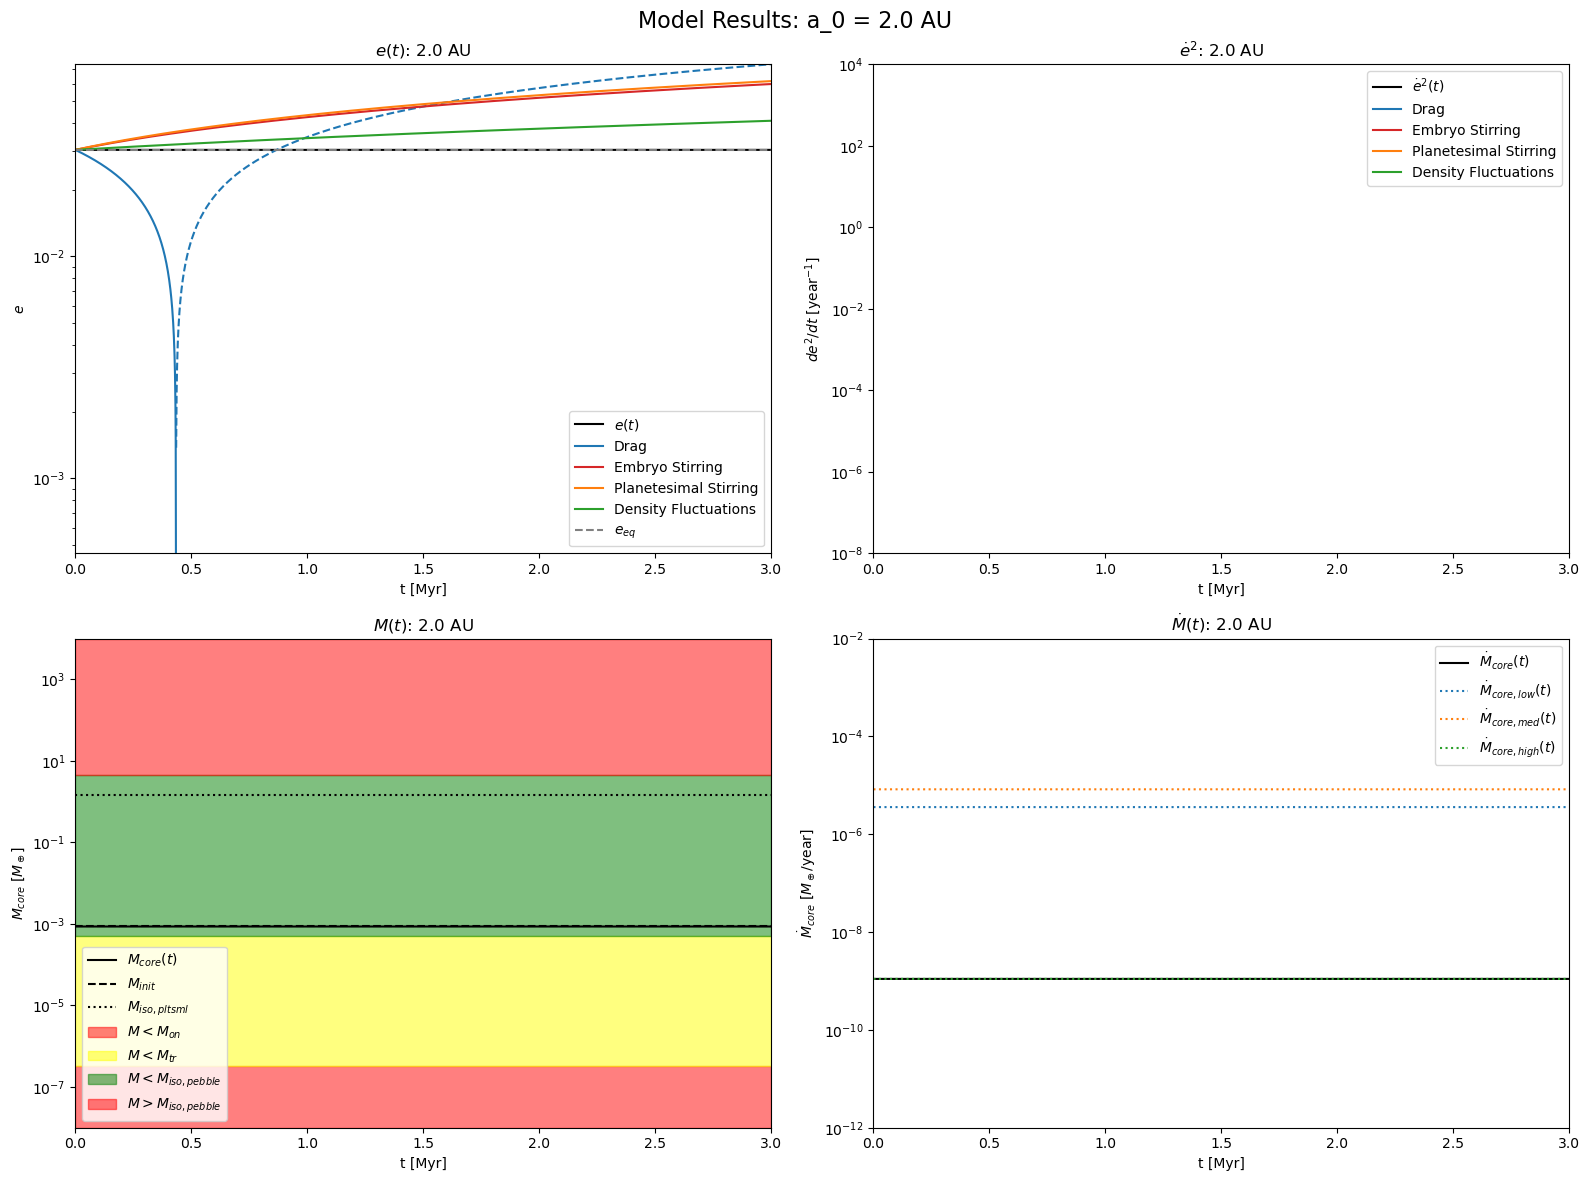

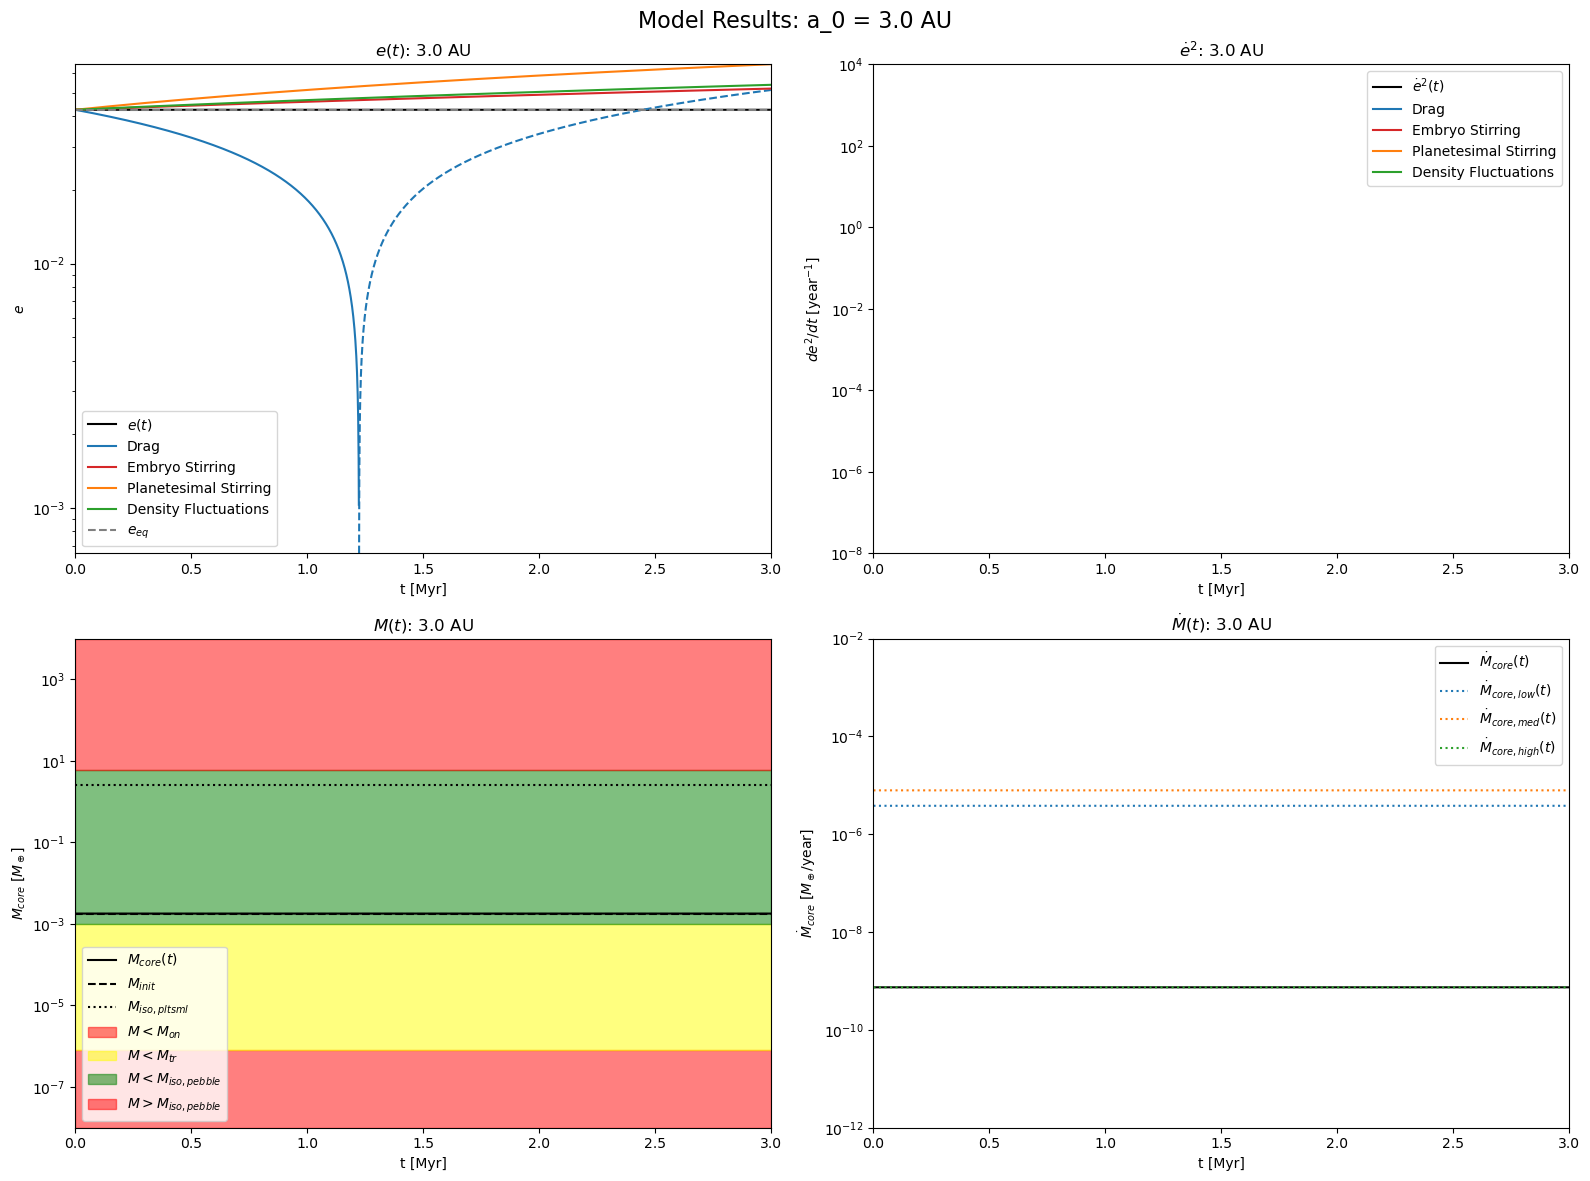

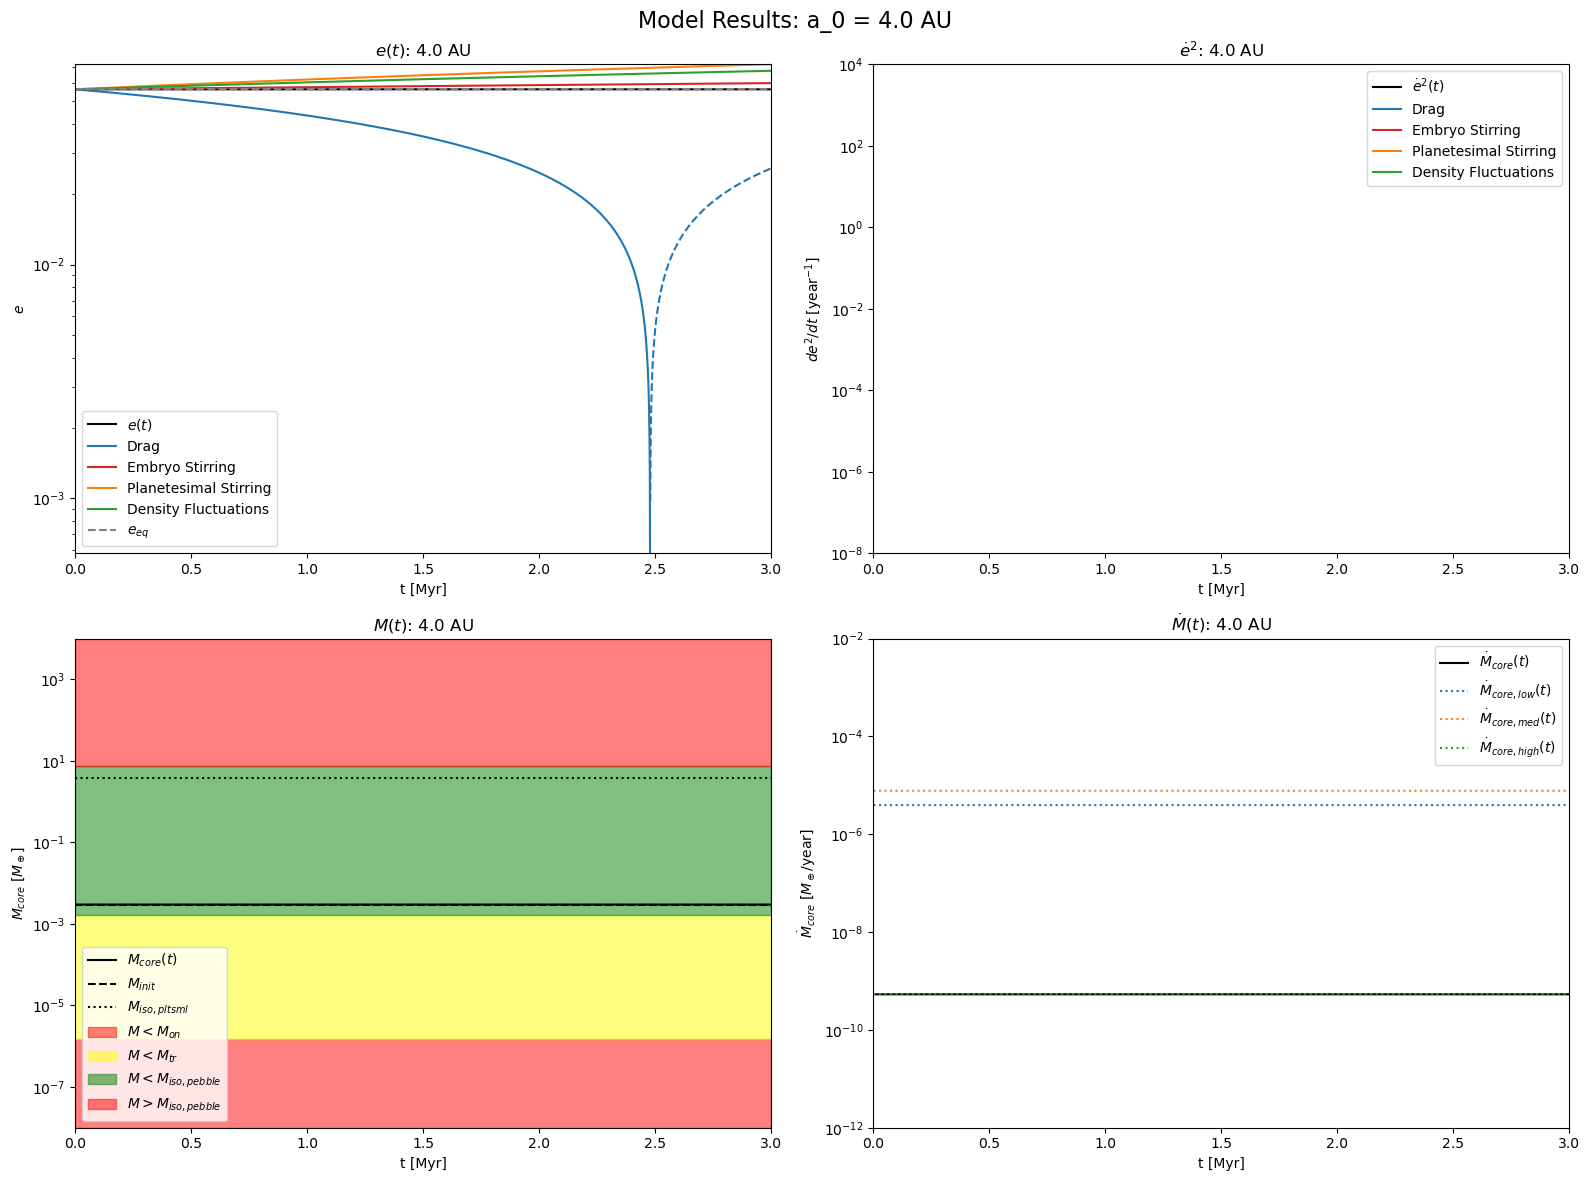

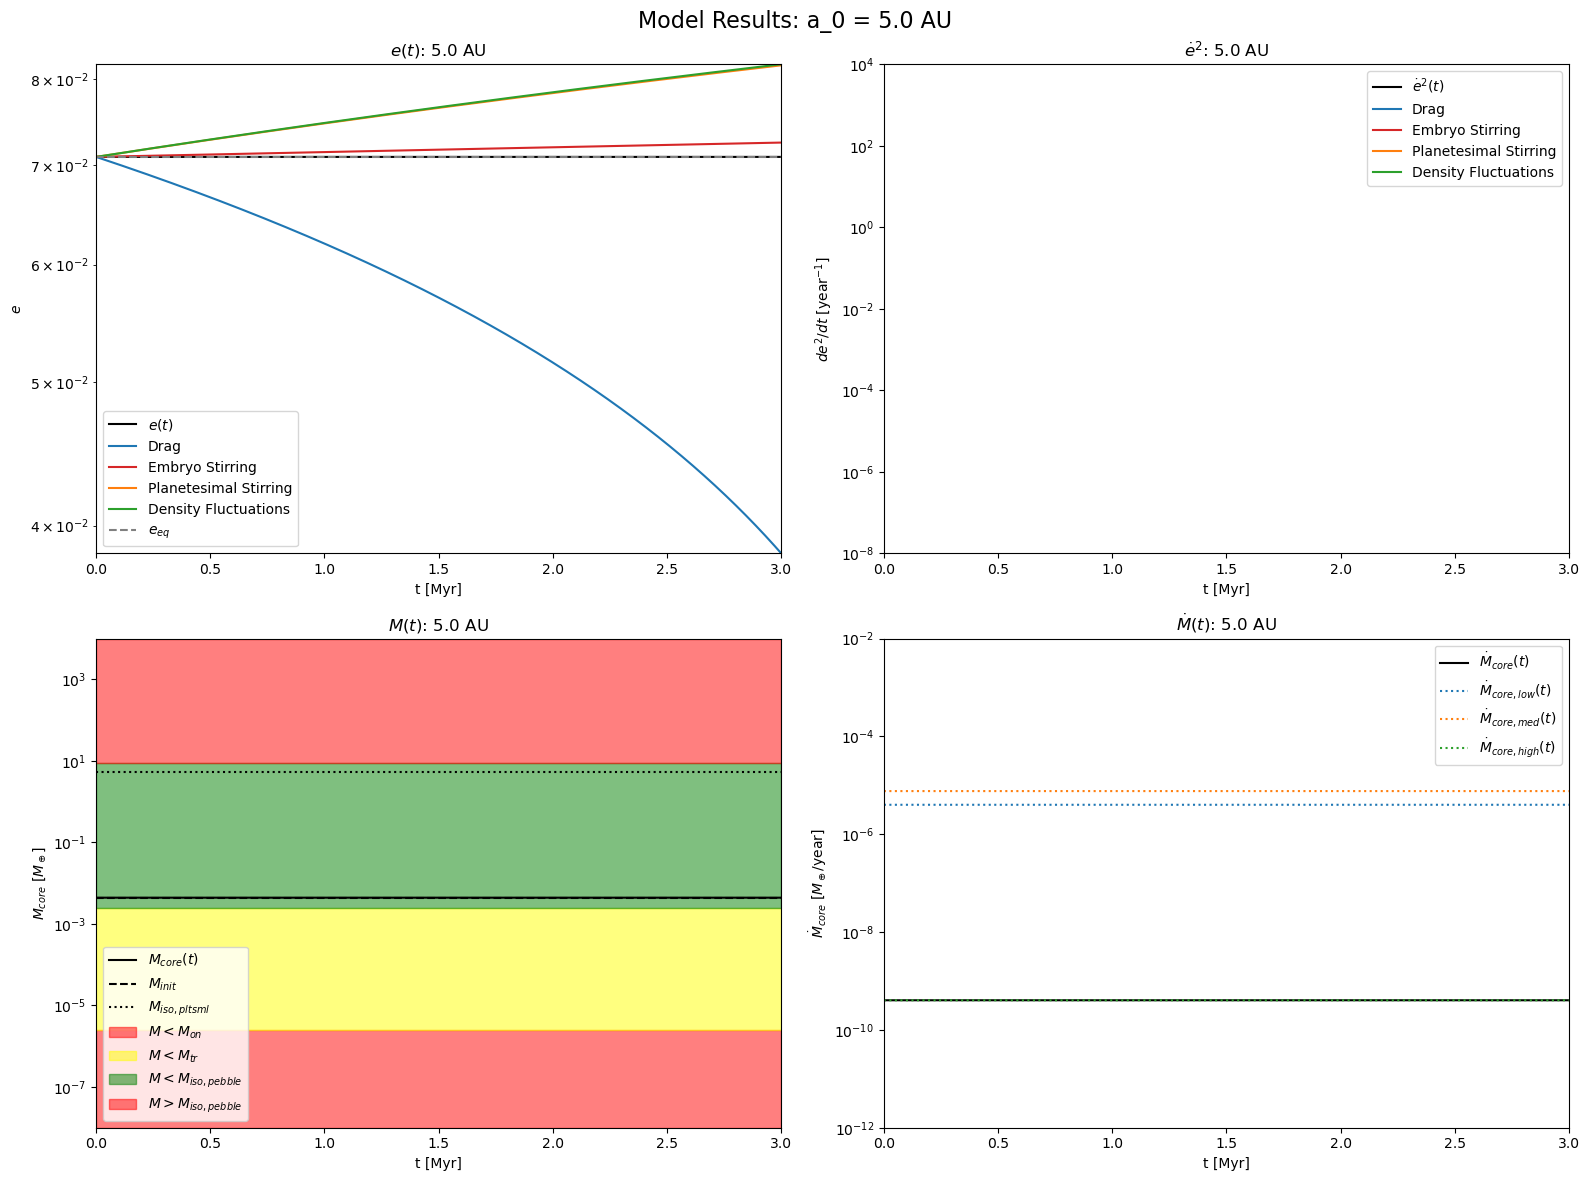

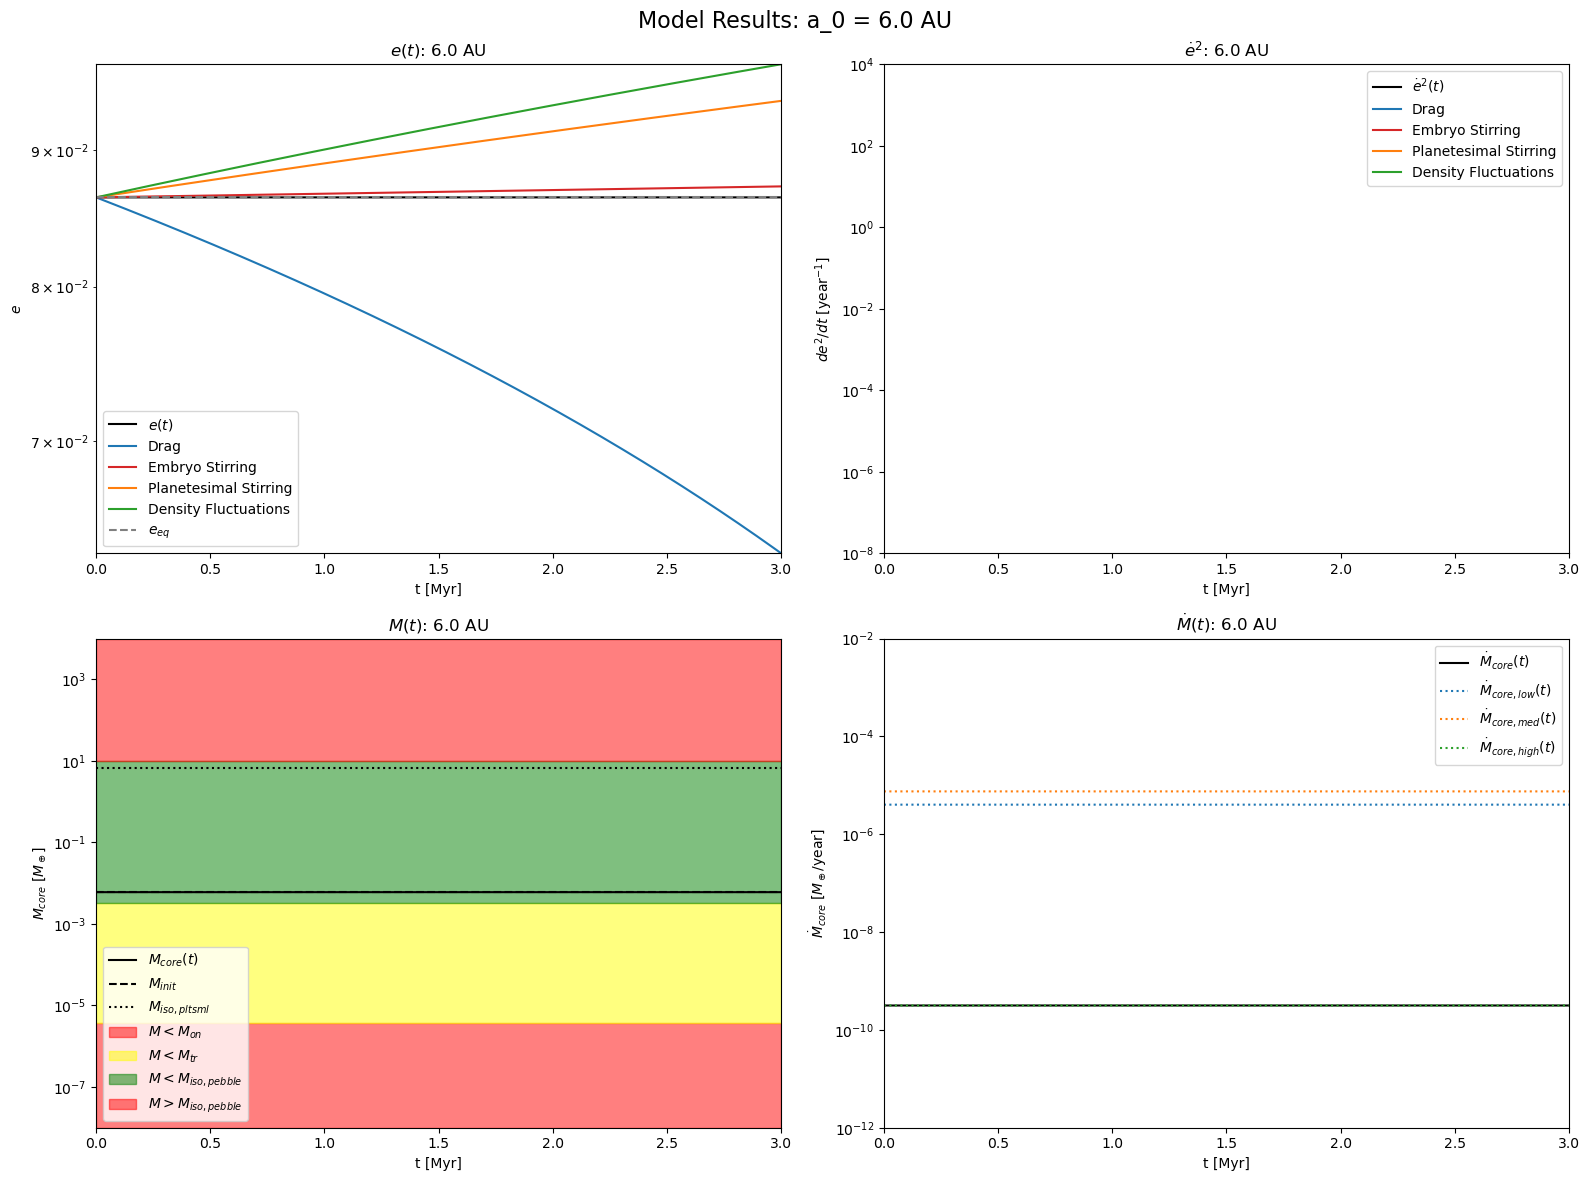

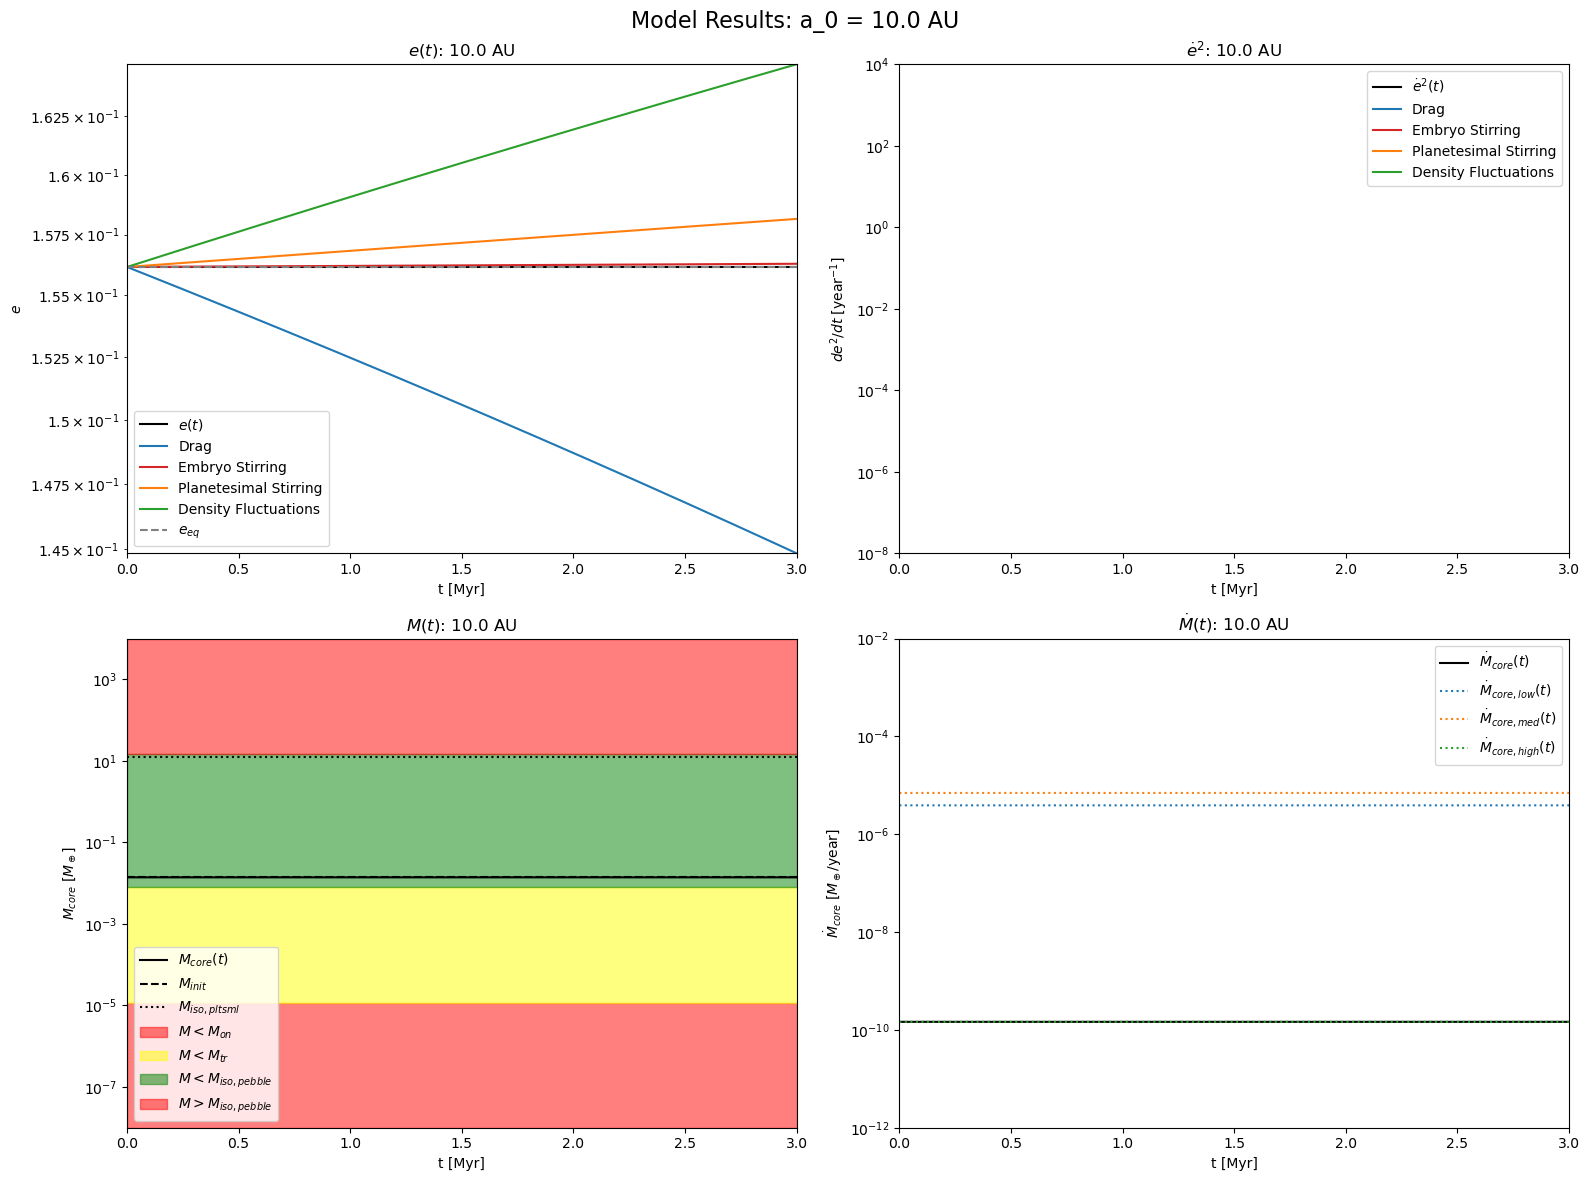

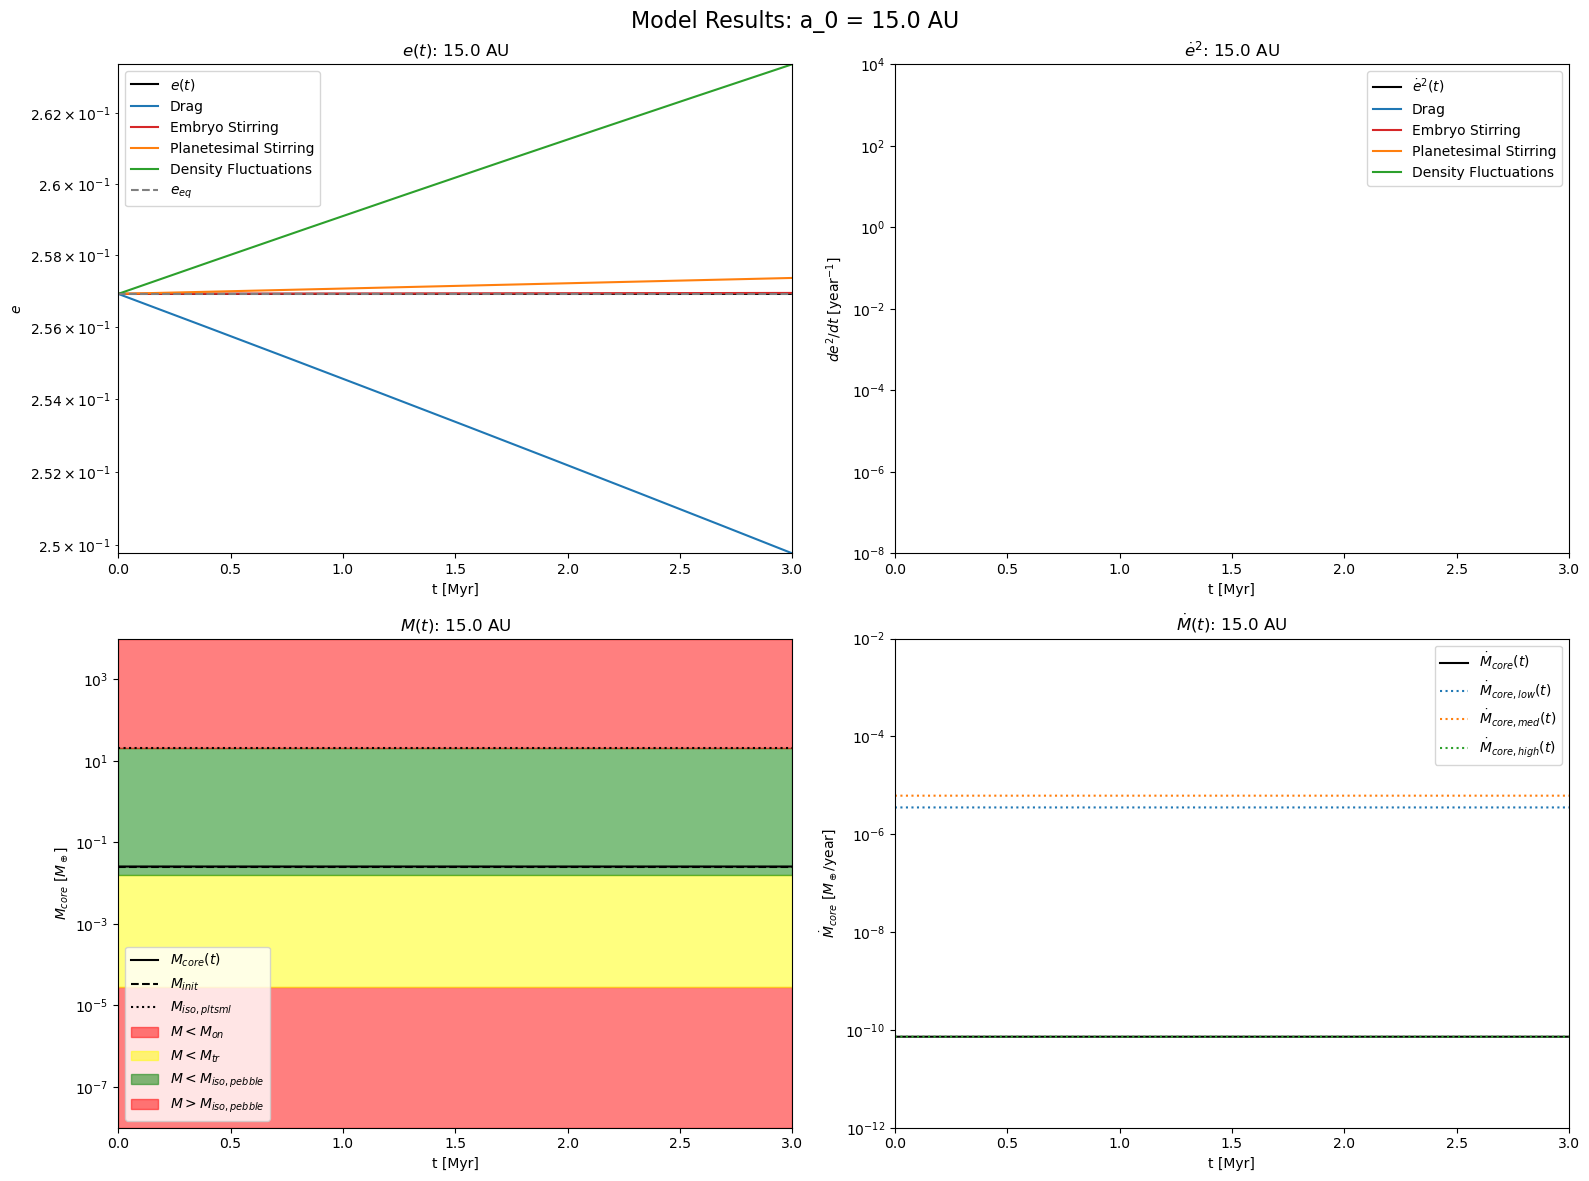

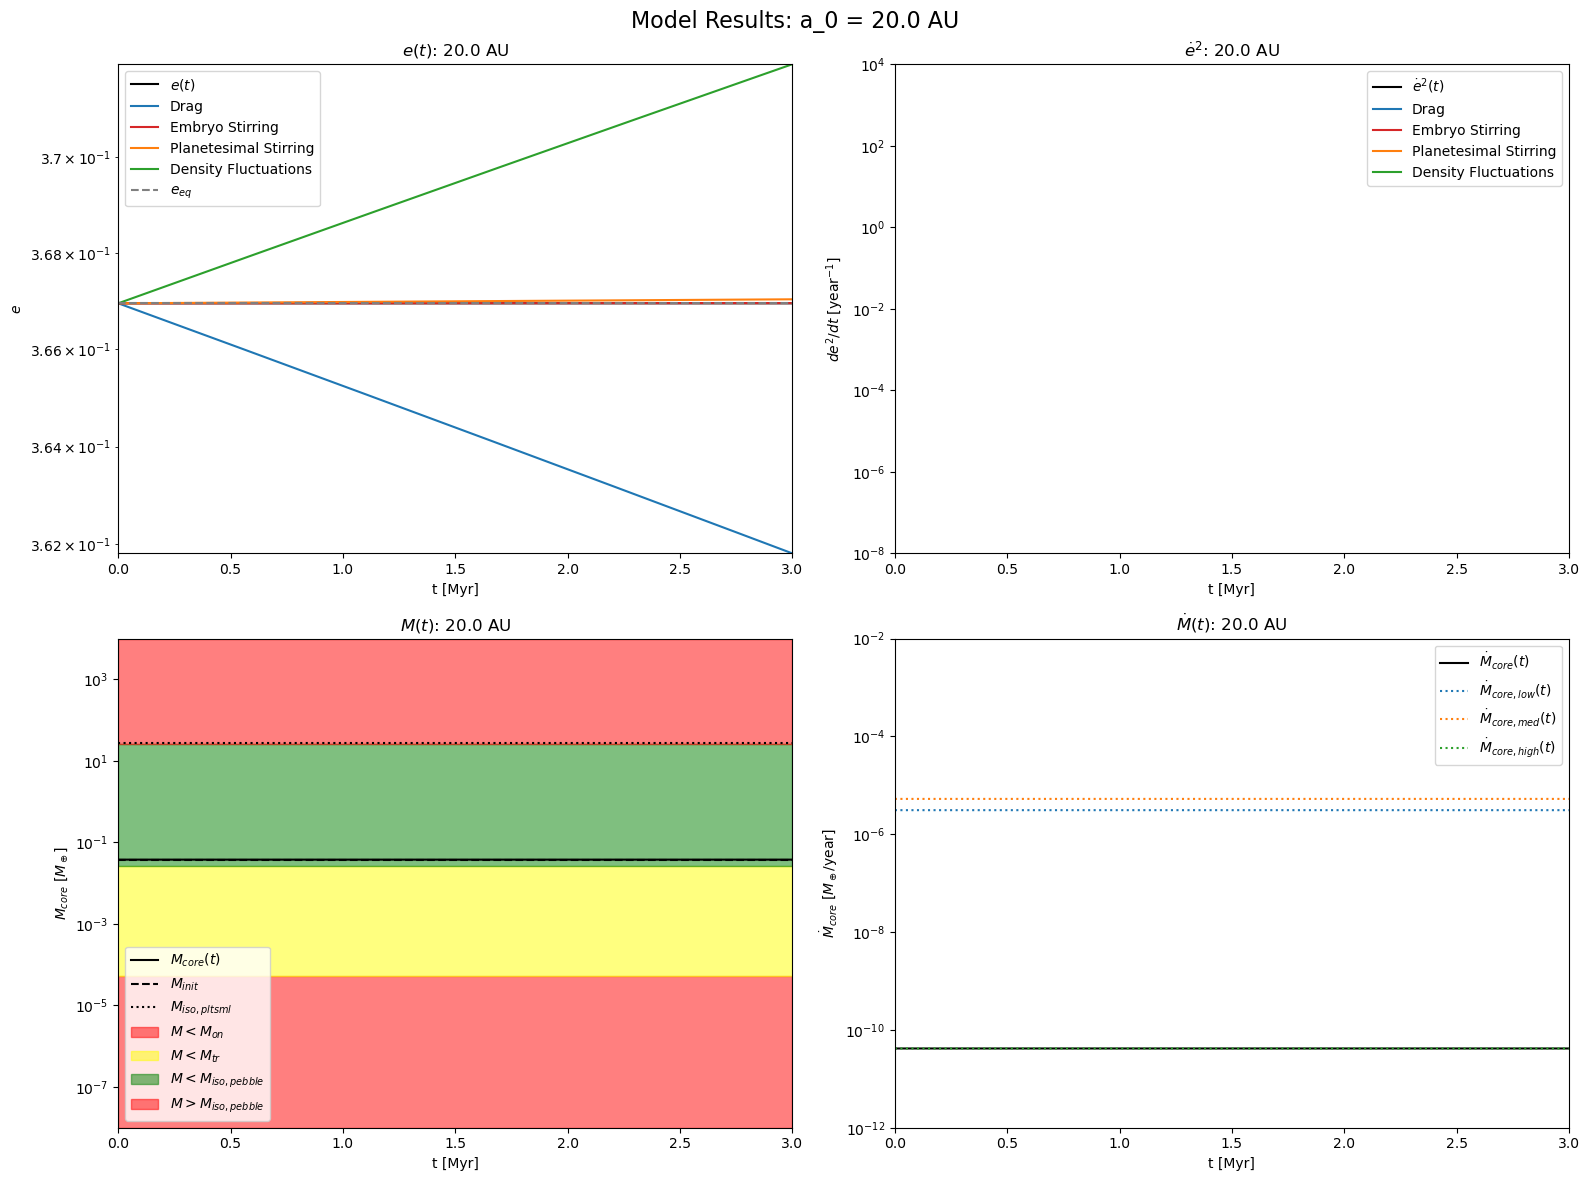

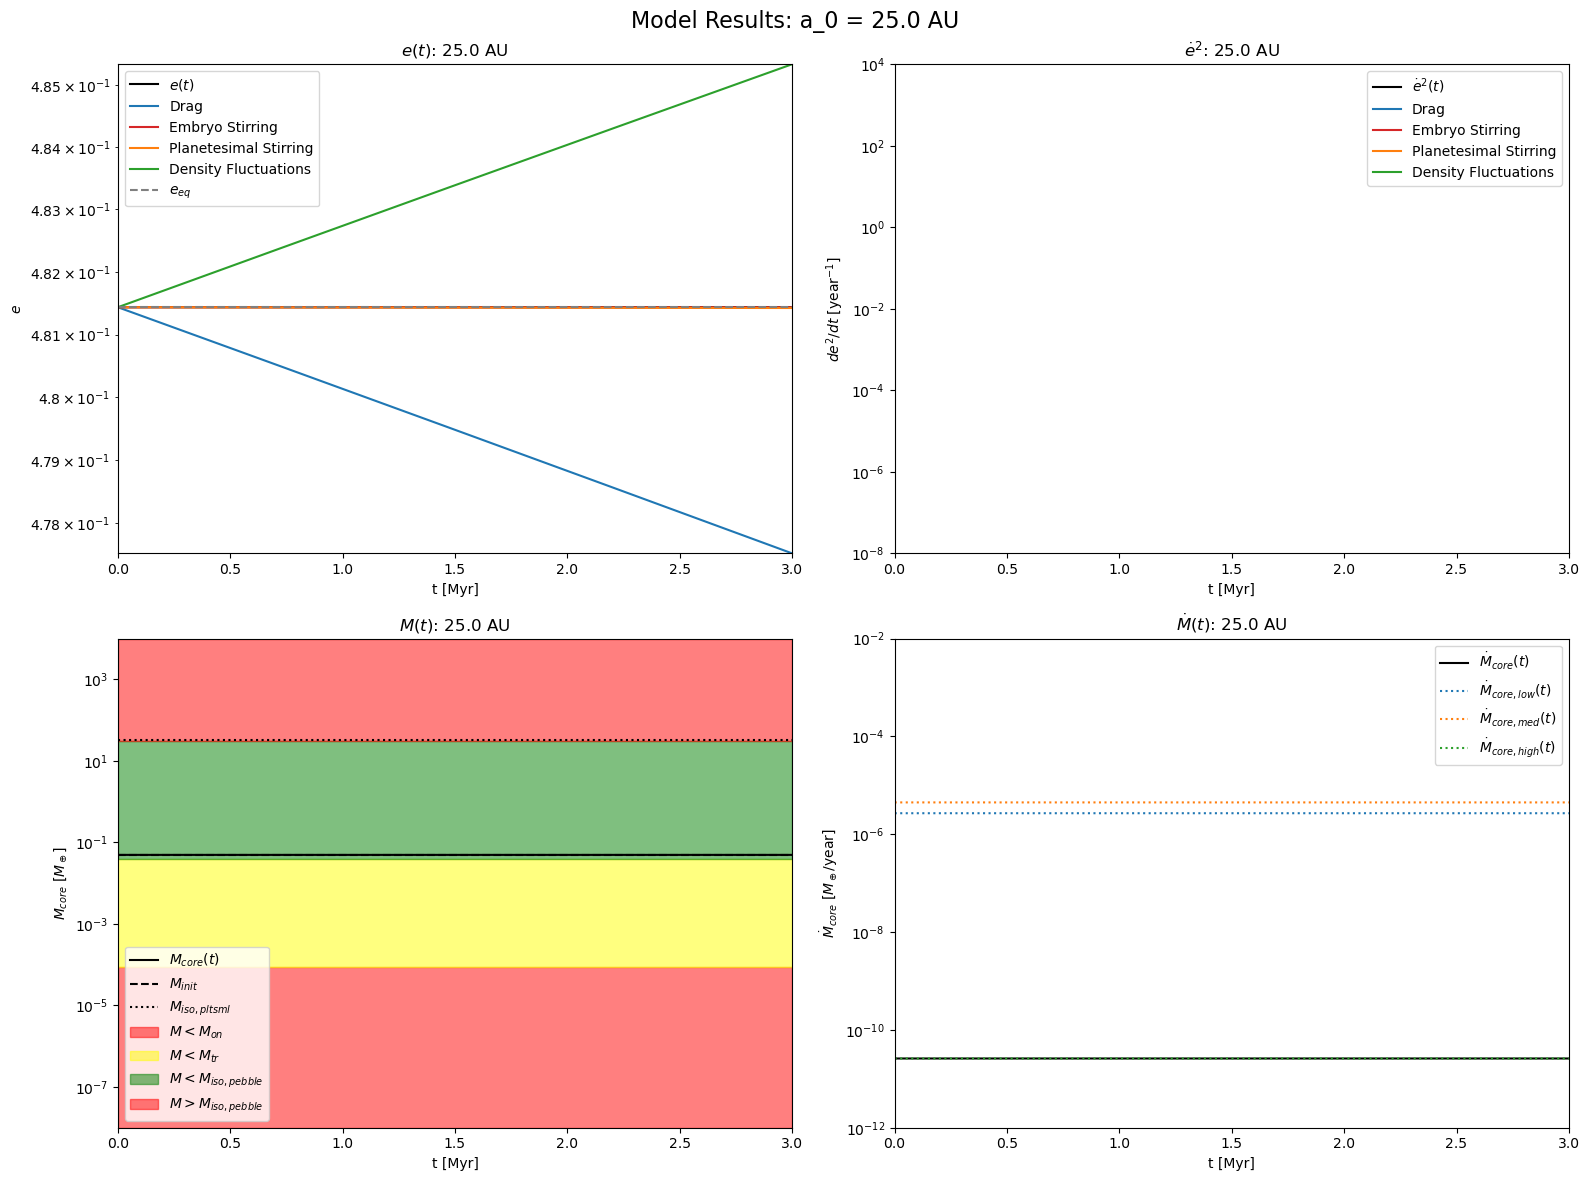

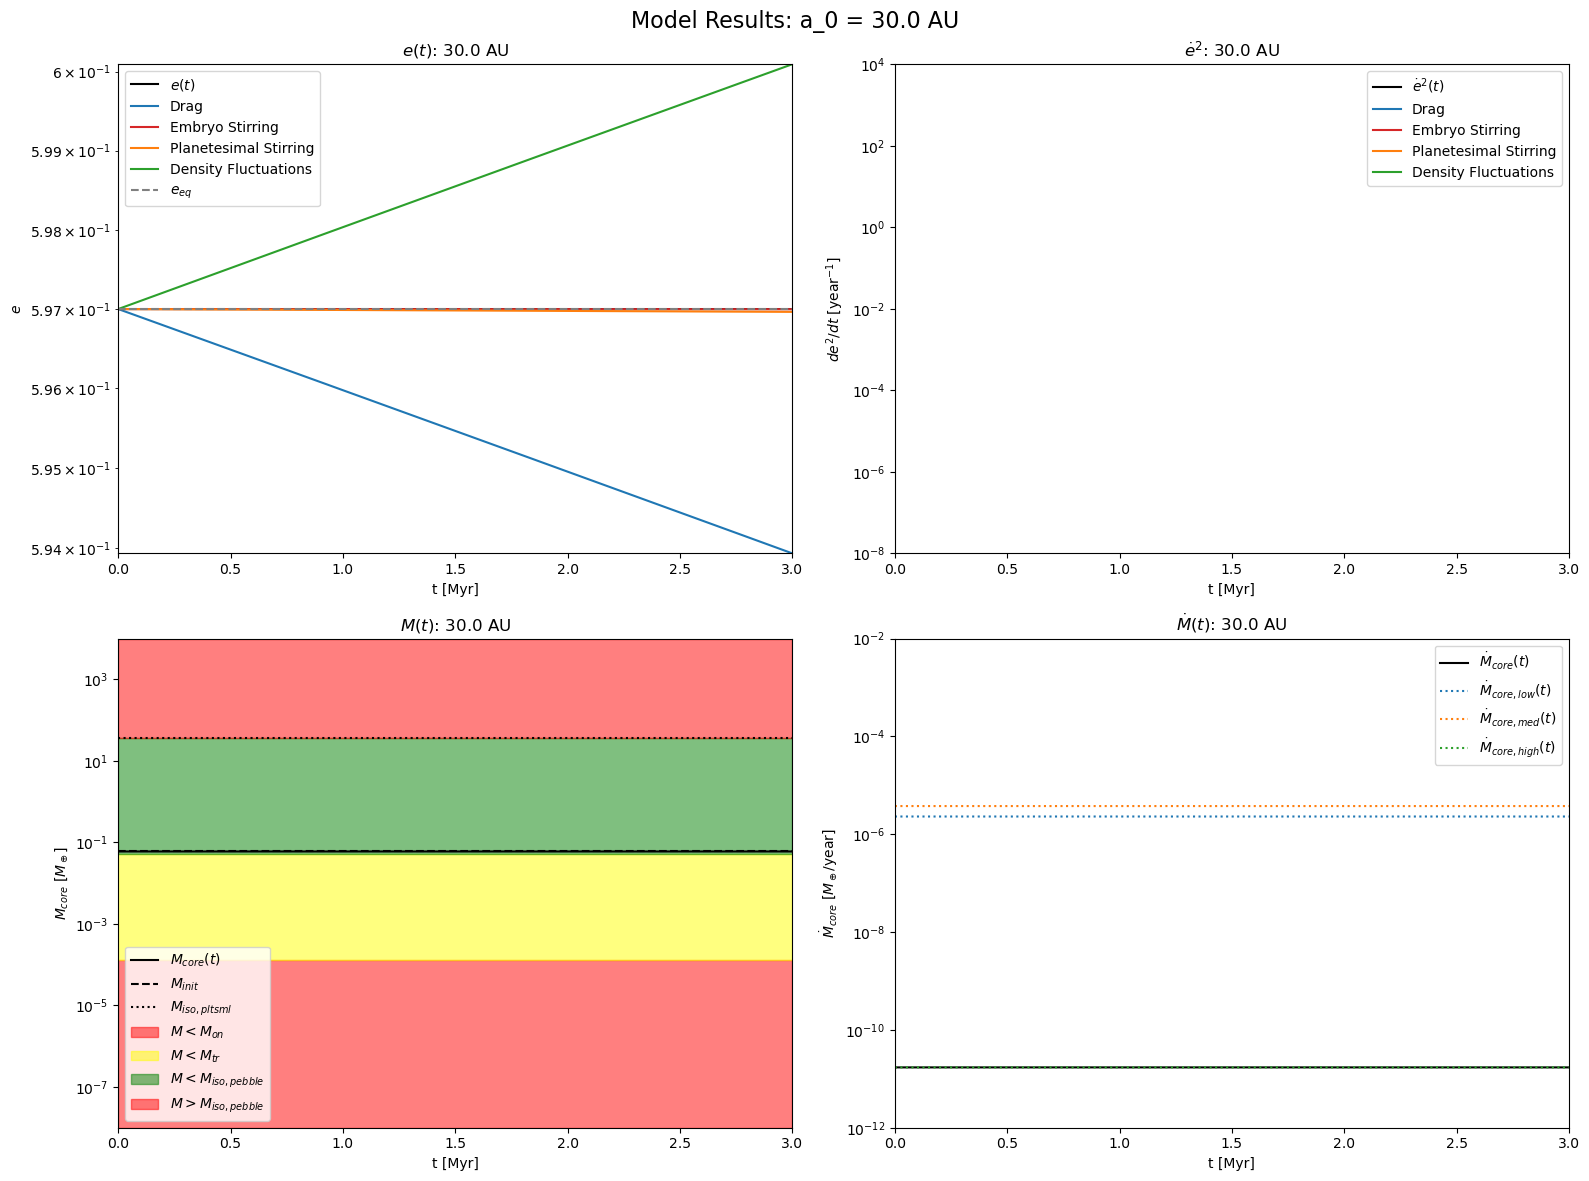

In [152]:
drag = True
VS_embryo = True
VS_pltsml = True
DF = True
accretion = True
scatter = True

a_cores = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 10.0, 15.0, 20.0, 25.0, 30.0]) # AU
M_disk = 0.1 # M_sun
t_end = 3.0 # Myr
t_interval = 1000 # years

filename = f'ncores_{len(a_cores)}_Mdisk_{M_disk}_tend_{t_end}_scatter'

output_dir = f'/Users/ben/Downloads/Planet Formation/Bern Model Simulations/Output/{filename}.h5'
figure_dir = f'/Users/ben/Downloads/Planet Formation/Bern Model Simulations/Figures/{filename}/'

## Check for existing results file

if os.path.exists(output_dir):
    print(f'Loading results from "{output_dir}"...')

    with h5py.File(output_dir, "r") as h5f:
        results = load_results(output_dir)

else:
    print(f'Running model and saving results to "{output_dir}"...')
    results = run_model(a_cores, t_end, t_interval, output_dir, drag, VS_embryo, VS_pltsml, DF, accretion, scatter)

## Plot results

print(f'Plotting results and saving figures to "{figure_dir}"...')
plot_results(a_cores, results, figure_dir)